In [2]:
import pandas as pd

data = pd.read_csv("/content/ev_charging_patterns.csv")

In [3]:
clients = {}

vehicle_models = data["Vehicle Model"].unique()

for model in vehicle_models:
    clients[model] = data[data["Vehicle Model"] == model]

print("Total Clients:", len(clients))

Total Clients: 5


Total Clients: 5

BMW i3 → RMSE: 1.42, R2: 1.00

Hyundai Kona → RMSE: 0.14, R2: 1.00

Chevy Bolt → RMSE: 0.54, R2: 1.00

Nissan Leaf → RMSE: 0.36, R2: 1.00

Tesla Model 3 → RMSE: 1.26, R2: 1.00

 Global Efficiency: 0.6585315621175987
 Global Battery Health: 92.79536853744928


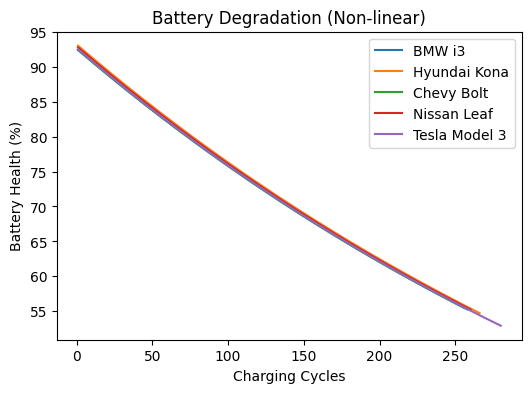

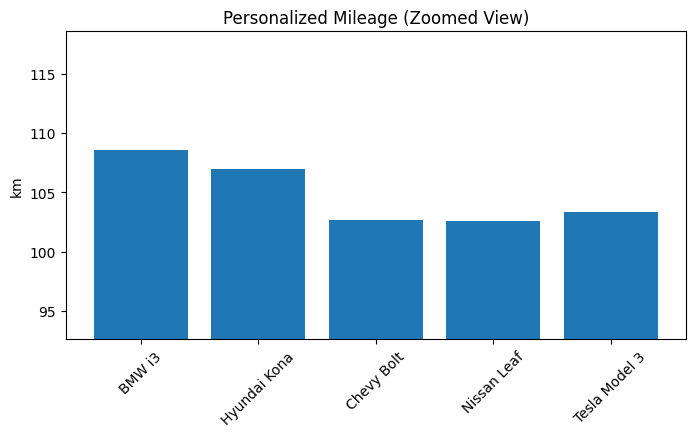


🔧 FINAL RESULTS:
BMW i3 → Mileage: 108.56 km | Health: 92.59% | Good Condition
Hyundai Kona → Mileage: 107.00 km | Health: 93.19% | Good Condition
Chevy Bolt → Mileage: 102.70 km | Health: 92.58% | Service Required
Nissan Leaf → Mileage: 102.59 km | Health: 92.95% | Service Required
Tesla Model 3 → Mileage: 103.34 km | Health: 92.67% | Service Required


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# 1. LOAD DATA
# -----------------------------
data = pd.read_csv("/content/ev_charging_patterns.csv")

# -----------------------------
# 2. CREATE REQUIRED FEATURES
# -----------------------------
if "Battery Capacity (kWh)" not in data.columns:
    data["Battery Capacity (kWh)"] = 100

if "Vehicle Age (years)" not in data.columns:
    data["Vehicle Age (years)"] = np.random.randint(1, 6, len(data))

if "Distance Driven (km)" not in data.columns:
    data["Distance Driven (km)"] = data["Charging Duration (hours)"] * 40

# -----------------------------
# 3. CREATE CLIENTS
# -----------------------------
clients = {}
vehicle_models = data["Vehicle Model"].unique()

for model in vehicle_models:
    clients[model] = data[data["Vehicle Model"] == model]

print("Total Clients:", len(clients))

# -----------------------------
# 4. LOCAL TRAINING
# -----------------------------
client_params = {}

for model_name, df in clients.items():

    df = df.copy()
    df = df.dropna()

    df["energy_per_km"] = df["Energy Consumed (kWh)"] / df["Distance Driven (km)"]

    df["battery_health"] = 100 - (df["Vehicle Age (years)"] * 2)

    df["effective_capacity"] = df["Battery Capacity (kWh)"] * (df["battery_health"]/100)

    features = [
        "Battery Capacity (kWh)",
        "Energy Consumed (kWh)",
        "Distance Driven (km)",
        "Vehicle Age (years)",
        "Temperature (°C)",
        "Charging Rate (kW)",
        "Charging Duration (hours)"
    ]

    X = df[features]
    y = df["Energy Consumed (kWh)"]

    model = RandomForestRegressor(n_estimators=50)
    model.fit(X, y)

    pred = model.predict(X)

    rmse = np.sqrt(mean_squared_error(y, pred))
    r2 = r2_score(y, pred)

    print(f"\n{model_name} → RMSE: {rmse:.2f}, R2: {r2:.2f}")

    avg_efficiency = df["energy_per_km"].mean()
    avg_health = df["battery_health"].mean()
    avg_capacity = df["effective_capacity"].mean()

    client_params[model_name] = {
        "efficiency": avg_efficiency,
        "battery_health": avg_health,
        "capacity": avg_capacity
    }

# -----------------------------
# 5. FEDERATED AGGREGATION
# -----------------------------
eff_list = []
health_list = []

for params in client_params.values():
    eff_list.append(params["efficiency"])
    health_list.append(params["battery_health"])

global_efficiency = np.mean(eff_list)
global_health = np.mean(health_list)

print("\n Global Efficiency:", global_efficiency)
print(" Global Battery Health:", global_health)

# -----------------------------
# 6. PERSONALIZED MILEAGE
# -----------------------------
client_mileage = {}

for model_name, params in client_params.items():

    local_capacity = params["capacity"]
    mileage = local_capacity / global_efficiency

    client_mileage[model_name] = mileage

    #print(f"{model_name} → Mileage: {mileage:.2f} km")

# -----------------------------
# 7. PERSONALIZED BATTERY HEALTH
# -----------------------------
client_battery_health = {}

for model_name, params in client_params.items():

    local_health = params["battery_health"]
    personalized_health = 0.7 * local_health + 0.3 * global_health

    client_battery_health[model_name] = personalized_health

    #print(f"{model_name} → Battery Health: {personalized_health:.2f}%")

# -----------------------------
# 8. SERVICE PREDICTION
# -----------------------------
service_results = {}

for model_name in client_mileage:

    mileage = client_mileage[model_name]
    health = client_battery_health[model_name]

    if mileage < 105 or health < 80:
        service = "Service Required"
    else:
        service = "Good Condition"

    service_results[model_name] = service

    #print(f"{model_name} → {service}")

# -----------------------------
# 9. NON-LINEAR BATTERY DECAY (FIXED)
# -----------------------------
plt.figure(figsize=(6,4))

for model_name, df in clients.items():

    df = df.copy()

    health_start = client_battery_health[model_name]

    df["cycle_count"] = range(1, len(df)+1)

    # Exponential decay (realistic)
    decay_rate = 0.002
    df["battery_decay"] = health_start * np.exp(-decay_rate * df["cycle_count"])

    plt.plot(df["cycle_count"], df["battery_decay"], label=model_name)

plt.title("Battery Degradation (Non-linear)")
plt.xlabel("Charging Cycles")
plt.ylabel("Battery Health (%)")
plt.legend()
plt.show()

# -----------------------------
# 10. ZOOMED MILEAGE PLOT (FIXED)
# -----------------------------
plt.figure(figsize=(8,4))

models = list(client_mileage.keys())
values = list(client_mileage.values())

plt.bar(models, values)

#  Zoom into difference range
min_val = min(values)
max_val = max(values)

plt.ylim(min_val - 10, max_val + 10)

plt.title("Personalized Mileage (Zoomed View)")
plt.ylabel("km")
plt.xticks(rotation=45)
plt.show()

# -----------------------------
# 11. FINAL SUMMARY
# -----------------------------
print("\n🔧 FINAL RESULTS:")
for model in client_mileage:
    print(f"{model} → Mileage: {client_mileage[model]:.2f} km | "
          f"Health: {client_battery_health[model]:.2f}% | "
          f"{service_results[model]}")